# 🧮 Vecteurs & Distances en Python (Mini-tutoriel 30 min)

Ce notebook propose un rappel mathématique des vecteurs et des principales distances/similarités,
avec des exemples concrets en **NumPy**.

## Objectifs
- Représenter des vecteurs avec **NumPy**
- Calculer des **normes** et **distances** (euclidienne, Manhattan)
- Calculer la **similarité** et la **distance** cosinus
- Comparer les distances retournées par **ChromaDB** avec un calcul **NumPy**
- Visualiser intuitivement en 2D


## 1) Préliminaires

In [1]:
import numpy as np
np.set_printoptions(precision=3, suppress=True)
print('NumPy version:', np.__version__)

NumPy version: 2.3.4


## 2) Représentation des vecteurs
Deux vecteurs dans $\mathbb{R}^3$.

In [2]:
v1 = np.array([1, 2, 3])
v2 = np.array([4, 0, 8])
print('v1 =', v1)
print('v2 =', v2)

v1 = [1 2 3]
v2 = [4 0 8]


## 3) Norme d'un vecteur
$$\|v\| = \sqrt{\sum_i v_i^2}$$

In [3]:
print('||v1|| =', np.linalg.norm(v1))
print('||v2|| =', np.linalg.norm(v2))

||v1|| = 3.7416573867739413
||v2|| = 8.94427190999916


## 4) Distances entre vecteurs
### a) Distance euclidienne
$$d_{euclid}(x, y) = \sqrt{\sum_i (x_i - y_i)^2}$$

In [4]:
dist_euclid = np.linalg.norm(v1 - v2)
print('Distance euclidienne =', dist_euclid)

Distance euclidienne = 6.164414002968976


### b) Distance de Manhattan (L1)
$$d_{manhattan}(x, y) = \sum_i |x_i - y_i|$$

In [5]:
dist_manhattan = np.sum(np.abs(v1 - v2))
print('Distance de Manhattan =', dist_manhattan)

Distance de Manhattan = 10


## 5) Similarité cosinus
La similarité cosinus mesure l'**alignement** entre deux vecteurs :
$$\cos(\theta) = \frac{x \cdot y}{\|x\|\,\|y\|}$$
Comprise entre -1 et 1 (en pratique des embeddings, souvent [0,1]).

In [6]:
dot = np.dot(v1, v2)
cosine_sim = dot / (np.linalg.norm(v1) * np.linalg.norm(v2))
print('Produit scalaire =', dot)
print('Similarité cosinus =', cosine_sim)

Produit scalaire = 28
Similarité cosinus = 0.8366600265340756


## 6) Distance cosinus
La **distance cosinus** transforme la similarité en distance :

$$d_{\text{cos}}(x, y) = 1 - \frac{x \cdot y}{\|x\|\,\|y\|}$$

- 0 ⇒ vecteurs alignés (très proches)
- Plus grand ⇒ vecteurs plus dissemblables

De nombreux outils (dont **ChromaDB** en espace `cosine`) renvoient cette **distance** (et non la similarité).

In [7]:
def cosine_similarity(a, b):
    a = np.asarray(a); b = np.asarray(b)
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return 0.0 if denom == 0 else float(np.dot(a, b) / denom)

def cosine_distance(a, b):
    return 1.0 - cosine_similarity(a, b)

print('Similarité cosinus (NumPy)  =', cosine_similarity(v1, v2))
print('Distance cosinus (1 - cos) =', cosine_distance(v1, v2))

Similarité cosinus (NumPy)  = 0.8366600265340756
Distance cosinus (1 - cos) = 0.16333997346592444


## 7) Entrer ces distances dans ChromaDB et comparer
Créons une collection **ChromaDB** en espace `cosine`, insérons `v1` et `v2`,
faisons une requête et comparons la **distance** renvoyée par ChromaDB avec `1 - cos` calculée à la main.

> Si nécessaire : `pip install chromadb` (à exécuter dans votre environnement local).

In [8]:
# !pip install chromadb  # à exécuter localement si besoin
import chromadb
import numpy as np

client = chromadb.Client()
collection = client.create_collection(
    name="compare_similarity",
    metadata={"hnsw:space": "cosine"}
)

In [9]:
collection.add(
    embeddings = [v1, v2],
    ids = ["id1", "id2"]
)

In [10]:
collection.peek()

{'ids': ['id1', 'id2'],
 'embeddings': array([[1., 2., 3.],
        [4., 0., 8.]]),
 'documents': [None, None],
 'uris': None,
 'included': ['metadatas', 'documents', 'embeddings'],
 'data': None,
 'metadatas': [None, None]}

In [12]:
results = collection.query(query_embeddings=v1, n_results=2)
results

{'ids': [['id1', 'id2']],
 'embeddings': None,
 'documents': [[None, None]],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[None, None]],
 'distances': [[1.1920928955078125e-07, 0.1633400321006775]]}

## 8) Mini-exercice
Générez 3 vecteurs aléatoires de dimension 2, calculez les **distances euclidiennes** et les **similarités cosinus**
pour chaque paire, puis identifiez la paire **la plus proche** (euclidienne minimale / cosinus maximal).

In [18]:
rng = np.random.default_rng(42)
vectors = rng.random((3, 2))
print('Vecteurs :\n', vectors)

best_pair_by_dist = None
best_dist = float('inf')
best_pair_by_cos = None
best_cos = -1.0

for i in range(3):
    for j in range(i+1, 3):
        dist = np.linalg.norm(vectors[i] - vectors[j])
        cos = np.dot(vectors[i], vectors[j]) / (np.linalg.norm(vectors[i]) * np.linalg.norm(vectors[j]))
        print(f'v{i} ↔ v{j} : dist = {dist:.3f}, cos = {cos:.3f}')
        if dist < best_dist:
            best_dist, best_pair_by_dist = dist, (i, j)
        if cos > best_cos:
            best_cos, best_pair_by_cos = cos, (i, j)

print(f'→ Paires les plus proches (euclidien) : v{best_pair_by_dist[0]}-v{best_pair_by_dist[1]} (dist={best_dist:.3f})')
print(f'→ Paires les plus similaires (cosinus) : v{best_pair_by_cos[0]}-v{best_pair_by_cos[1]} (cos={best_cos:.3f})')

Vecteurs :
 [[0.774 0.439]
 [0.859 0.697]
 [0.094 0.976]]
v0 ↔ v1 : dist = 0.272, cos = 0.986
v0 ↔ v2 : dist = 0.866, cos = 0.575
v1 ↔ v2 : dist = 0.813, cos = 0.702
→ Paires les plus proches (euclidien) : v0-v1 (dist=0.272)
→ Paires les plus similaires (cosinus) : v0-v1 (cos=0.986)


## 9) Visualisation (2D)

Avec matplotlib visualisez les vecteurs précédents dans un plan 2D.

In [19]:
vectors

array([[0.774, 0.439],
       [0.859, 0.697],
       [0.094, 0.976]])

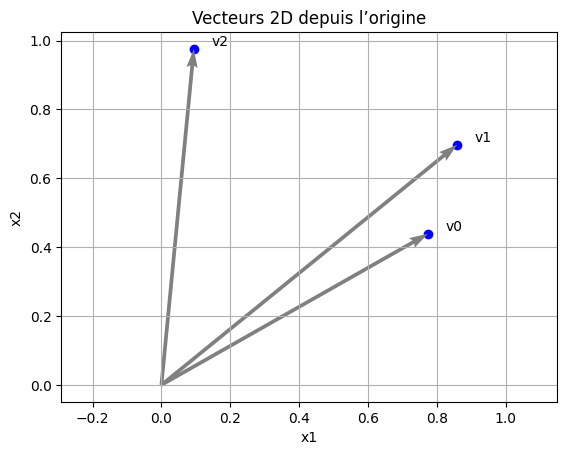

In [24]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()
# Tracé du nuage de points
plt.scatter(vectors[:,0], vectors[:,1], color='blue')

# Tracé des flèches depuis l'origine vers chaque point
plt.quiver(
    np.zeros(len(vectors)),  # origine x
    np.zeros(len(vectors)),  # origine y
    vectors[:,0],            # composante x du vecteur
    vectors[:,1],            # composante y du vecteur
    angles='xy', scale_units='xy', scale=1, color='gray'
)

# Étiquettes
for i,(x,y) in enumerate(vectors):
    plt.text(x+0.05, y+0.01, f'v{i}')

plt.title('Vecteurs 2D depuis l’origine')
plt.xlabel('x1')
plt.ylabel('x2')
plt.axis('equal')
plt.grid(True)
plt.show()


## 10) Lien avec ChromaDB
- Les **embeddings** sont des vecteurs $x \in \mathbb{R}^n$.
- Une requête devient un vecteur $q$ ; on cherche les vecteurs stockés **les plus proches**.
- En espace `cosine`, Chroma renvoie des **distances** (petit = similaire).
- Les index ANN accélèrent ces recherches.

---
### Bonus : fonctions utilitaires

In [14]:
def euclidean_distance(x: np.ndarray, y: np.ndarray) -> float:
    return float(np.linalg.norm(x - y))

def manhattan_distance(x: np.ndarray, y: np.ndarray) -> float:
    return float(np.sum(np.abs(x - y)))

def cosine_similarity(x: np.ndarray, y: np.ndarray) -> float:
    denom = np.linalg.norm(x) * np.linalg.norm(y)
    if denom == 0:
        return 0.0
    return float(np.dot(x, y) / denom)
